### What is PCA?
Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique used to transform a high-dimensional dataset into a lower-dimensional representation while preserving as much information (variance) as possible.

Instead of working with hundreds or thousands of features, PCA creates a smaller number of new features called Principal Components (PCs).

These components:
* Are linear combinations of original features
* Are mutually orthogonal (uncorrelated)
* Capture maximum variance in descending order

### Why PCA Exists
Modern datasets often contain:
* Hundreds of features
* Correlated variables
* Redundant information
* Noise

Problems caused by high dimensionality:

#### Computational Cost
More features → More computations.

#### Storage Cost
More columns → Larger datasets.

#### Visualization Difficulty
Humans can visualize only:
* 1D
* 2D
* 3D

#### Curse of Dimensionality
Distance-based algorithms become ineffective.

Examples:
* K-Means
* DBSCAN
* KNN

Example

##### Customer dataset:
| Customer | Age | Salary | Spending |
| -------- | --- | ------ | -------- |
| C1       | 25  | 40000  | 2000     |
| C2       | 30  | 50000  | 3000     |
| C3       | 35  | 60000  | 4000     |

Observe:

Salary and Spending are strongly correlated.

PCA compresses these features into fewer dimensions while retaining most information.

### Core Idea Behind PCA
PCA searches for directions where data varies the most.

Consider a 2D dataset:

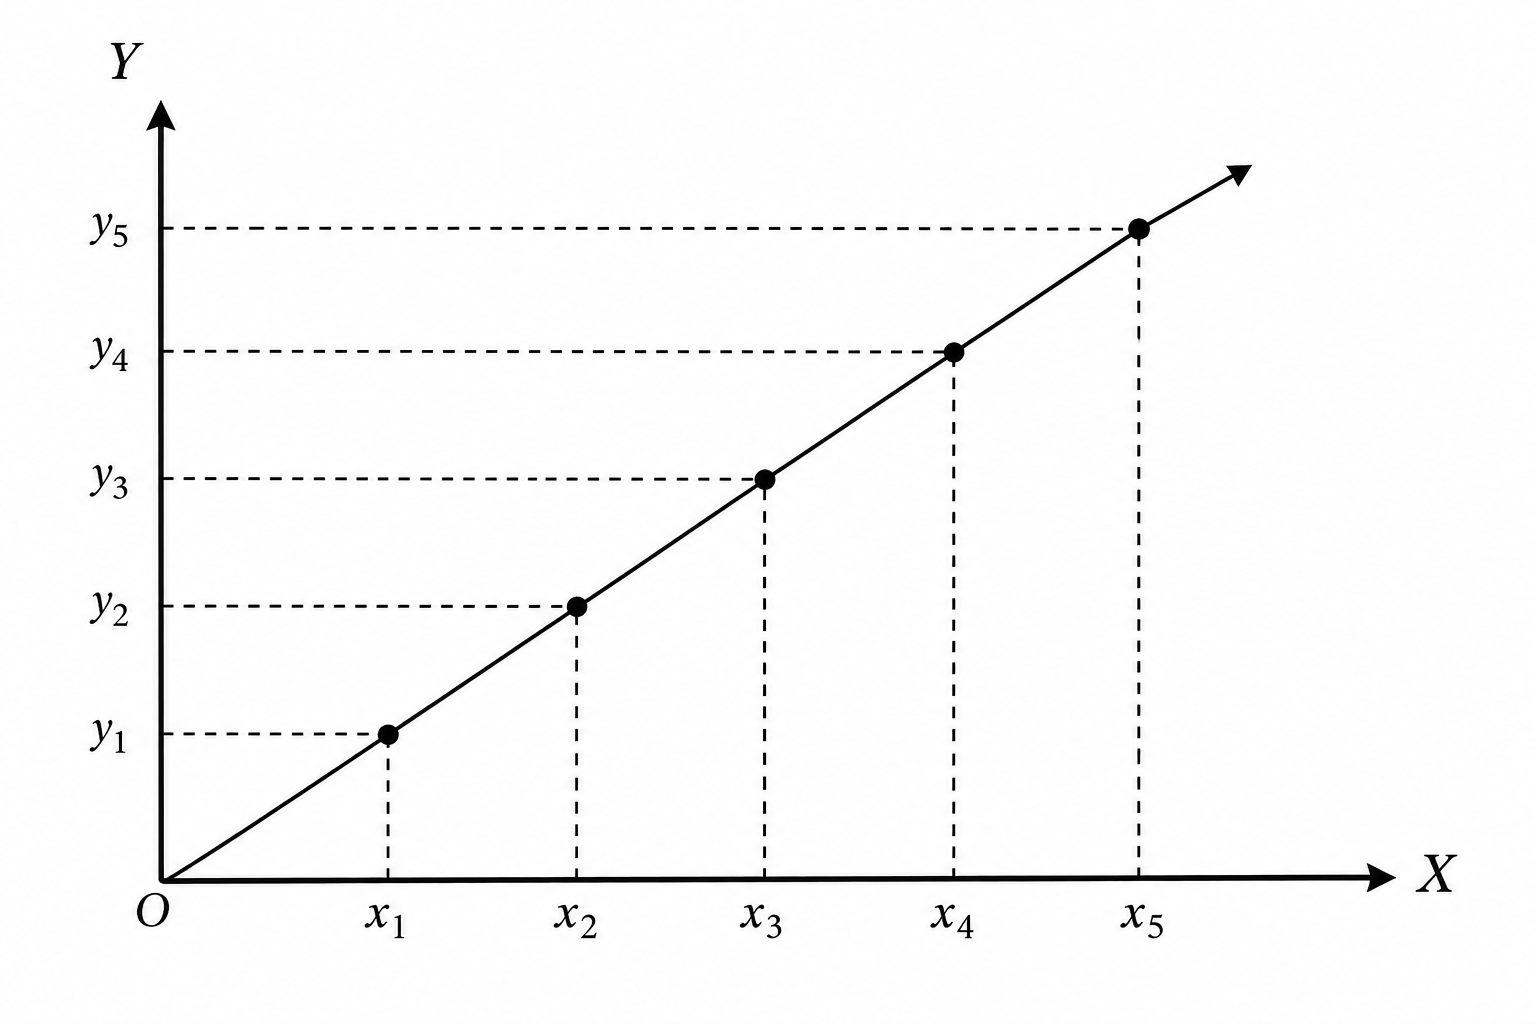

Data mainly spreads diagonally.

Instead of keeping:
* X-axis
* Y-axis

PCA creates:
* PC1 → diagonal direction
* PC2 → perpendicular direction

#### Visual Intuition
##### PCA Rotated Axes

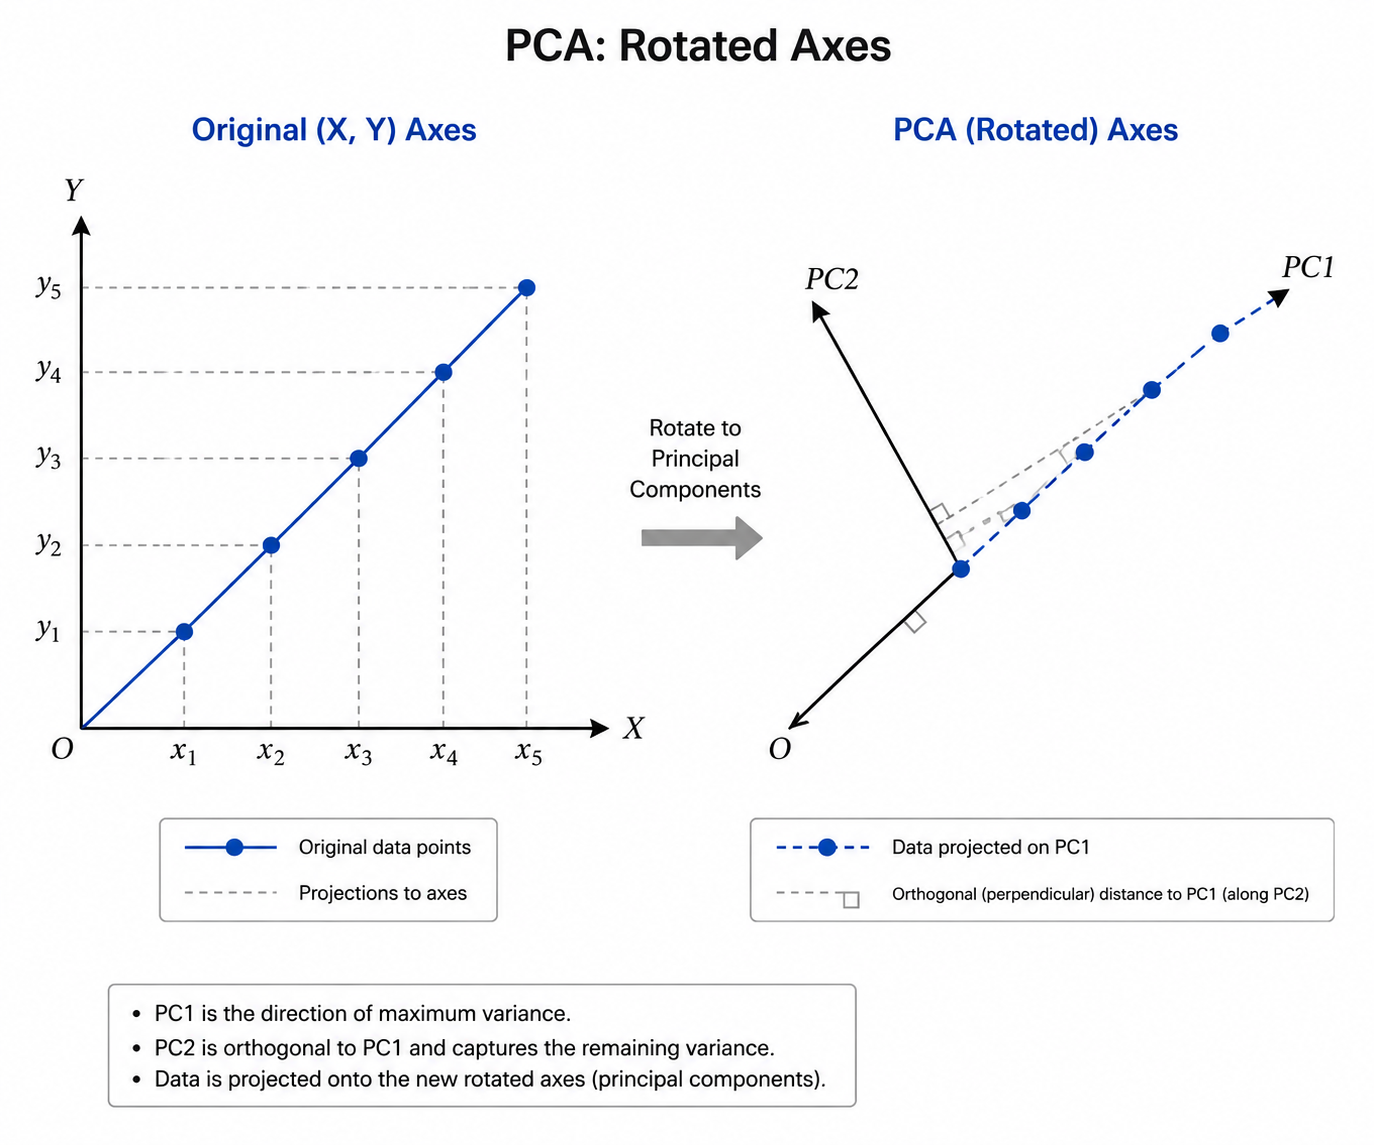

Most information lies on PC1.

PC2 contributes very little.

Therefore:

Keep PC1 and discard PC2.

### What is Variance?
Variance measures data spread.

Formula:
$$
\mathrm{Var}(X)
=
\frac{1}{n}
\sum_{i=1}^{n}
(x_i - \mu)^2
$$

Large variance:

```text
1 4 7 10 13
```

Small variance:

```text
5 5 6 5 4
```

PCA seeks directions with maximum variance.

### Principal Components
Principal Components are:

New variables created from original features.

Properties:

#### PC1
Captures maximum variance.

#### PC2
Captures next maximum variance.

Constraint:

```text
PC2 ⊥ PC1
```

#### PC3
Captures next maximum variance.

Constraint:

```text
PC3 ⊥ PC1 and PC2
```

And so on.

### Mathematical Foundation
Assume dataset:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1p} \\
x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
$$

Rows = samples

Columns = features

### PCA Workflow

#### Step 1: Standardization
Features must be scaled.

Example:

| Feature | Range    |
| ------- | -------- |
| Age     | 20-60    |
| Salary  | 20K-500K |

Without scaling:

Salary dominates.

Use:
$$
z = \frac{x - \mu}{\sigma}
$$

Result:
* Mean = 0
* Std = 1

#### Step 2: Covariance Matrix
Measure feature relationships.

For features X and Y:
$$
\operatorname{Cov}(X, Y)
=
\frac{1}{n - 1}
\sum_{i=1}^{n}
\left( X_i - \mu_X \right)
\left( Y_i - \mu_Y \right)
$$

##### Covariance Interpretation

**Positive:**
```text
X ↑ → Y ↑
```

**Negative:**
```text
X ↑ → Y ↓
```

**Zero:**

No linear relationship.

**Covariance Matrix:**

$$
C =
\begin{bmatrix}
\operatorname{Var}(X_1) & \operatorname{Cov}(X_1, X_2) \\
\operatorname{Cov}(X_2, X_1) & \operatorname{Var}(X_2)
\end{bmatrix}
$$

#### Step 3: Eigenvectors and Eigenvalues
This is the heart of PCA.

For covariance matrix:
$$
Cv=λv
$$

Where:
* $v$ = Eigenvector
* $λ$ = Eigenvalue

##### Eigenvector
An eigenvector is:
> A direction that remains unchanged after transformation.

For PCA:

Eigenvectors become: **Principal Component Directions**

Direction of maximum variance.

##### Eigenvalue
Eigenvalue tells:
> How much variance exists along that eigenvector.

Large eigenvalue:
```
Important direction, more information captured.
```
Small eigenvalue:
```
Less important, less information captured.
```


#### Step 4: Sort Eigenvalues
Suppose:

| Component | Eigenvalue |
| --------- | ---------- |
| PC1       | 8          |
| PC2       | 2          |
| PC3       | 0.5        |

Importance:

```text
PC1 > PC2 > PC3
```

##### Explained Variance
Explained Variance Ratio:
$$
\frac{\lambda_i}{\sum{\lambda}}
$$

Example:

Eigenvalues:
```text
8, 2
```

Total:
```text
10
```

PC1:
```text
8/10 = 80%
```

PC2:
```text
2/10 = 20%
```

Interpretation:

PC1 alone captures 80% information.

#### Step 5: Feature Projection
Project data onto selected components.

Transformation:
$$
Z=XV
$$

Where:

* X = original data
* V = principal components

Result:

Reduced dataset.

### Geometric Interpretation
Original Data
```
(X,Y)
```

Rotate axes

Project points

Keep strongest directions

Reduced data

### Choosing Number of Components
Several methods exist.

#### Method 1: Explained Variance Threshold
Keep components until:
```text
95%
```
variance retained.

Example:

| Component | Variance |
| --------- | -------- |
| PC1       | 60%      |
| PC2       | 25%      |
| PC3       | 10%      |
| PC4       | 5%       |

Keep:

```text
PC1 + PC2 + PC3 = 95%
```

#### Method 2: Scree Plot
Plot:

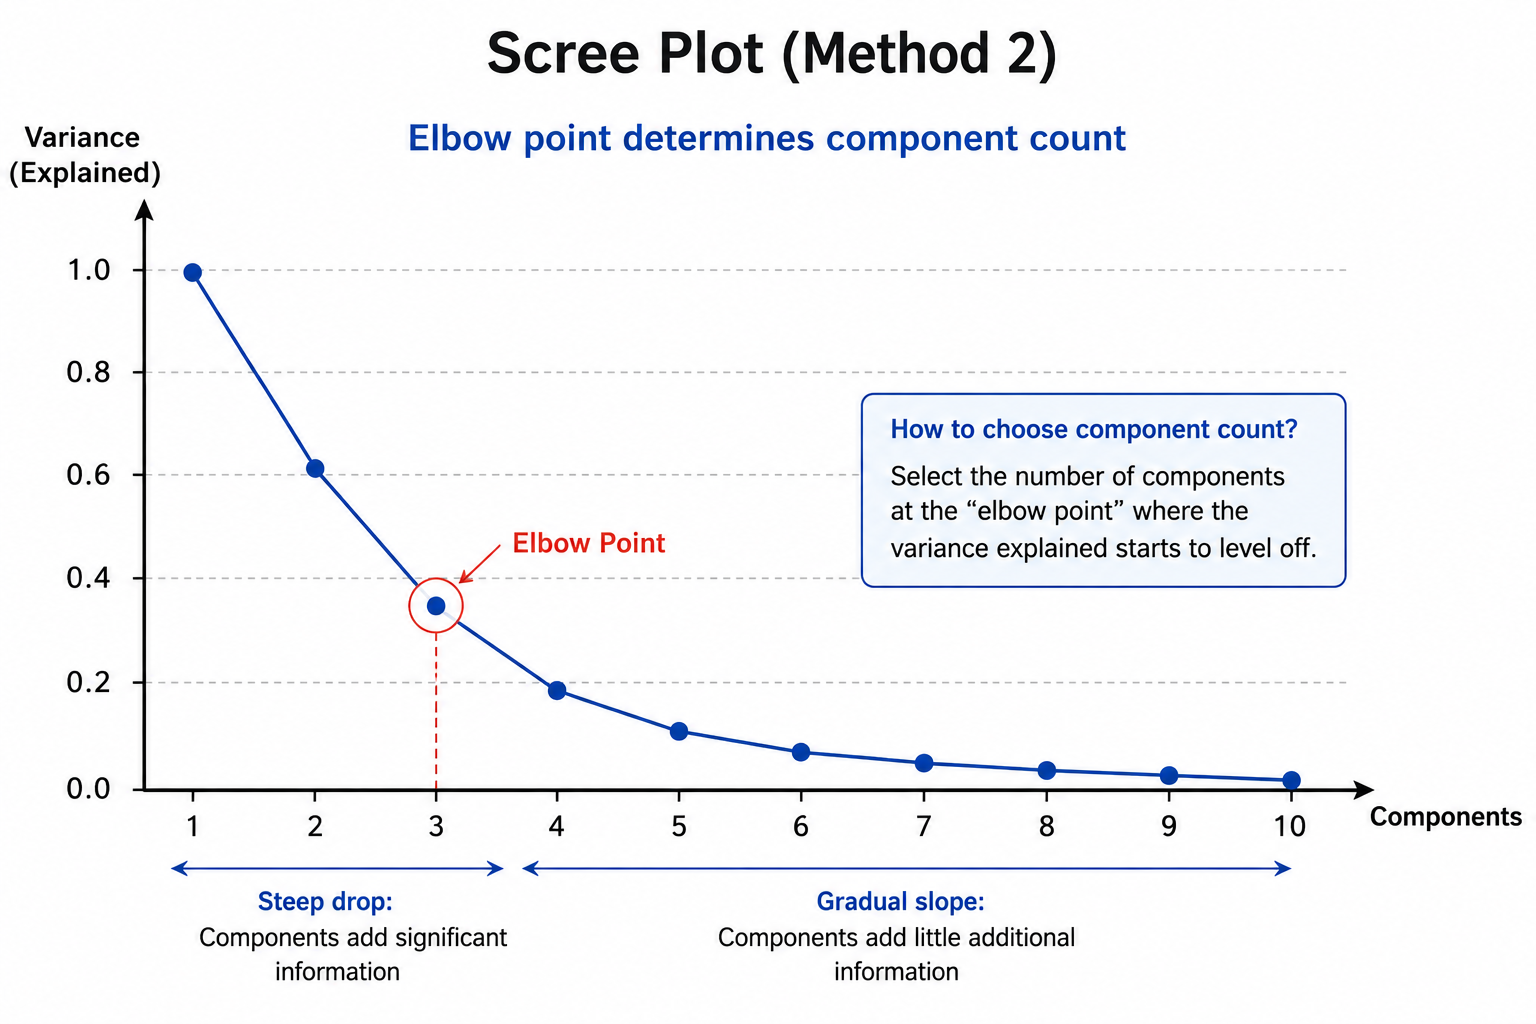

Elbow point determines component count.

### Loadings
Loadings show contribution of original features.

Example:

| Feature  | PC1  |
| -------- | ---- |
| Salary   | 0.82 |
| Spending | 0.78 |
| Age      | 0.15 |

Interpretation:

PC1 mainly represents:

```text
Salary + Spending
```

### PCA in Scikit-Learn
```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)
```

**Explained Variance:**
```python
pca.explained_variance_ratio_
```

**Components:**
```python
pca.components_
```

### PCA for Visualization
Suppose:

Dataset has:
```text
500 features
```

Impossible to visualize.

PCA:
```python
PCA(n_components=2)
```

Produces:
```text
2 dimensions
```

Suitable for plotting.

### PCA for Noise Reduction
Signal:
* PC1
* PC2
* PC3

Noise:
* PC20
* PC21
* PC22

Discard low-variance components.

Result:

Cleaner dataset.

### PCA for Feature Compression
Original:
```text
1000 features
```

After PCA:
```text
50 features
```

Storage reduction:
```text
95%
```

Training becomes significantly faster.

### PCA and Correlation
Highly correlated features:
* Income
* Salary
* Annual Earnings

contain duplicate information.

PCA combines them into fewer components.

### PCA vs Feature Selection
#### Feature Selection
Keeps original columns.

Example:
```
Age
Salary
```
selected from:
```
Age
Salary
Gender
Income
```
#### PCA
Creates entirely new features.

Example:
```
PC1
PC2
```
Original meaning is lost.

### Advantages
#### Reduces dimensionality
Less storage.

#### Faster training
Fewer features.

#### Removes multicollinearity
Useful for linear models.

#### Noise reduction
Improves generalization.

#### Visualization
High-dimensional data becomes interpretable.

### Disadvantages
#### Loss of Interpretability
PC1 and PC2 are not business-friendly.

Example:
```text
0.54 × Salary
+
0.42 × Spending
-
0.19 × Age
```

Hard to explain.

#### Information Loss
Removing components discards variance.

#### Linear Method
Captures only linear relationships.

Cannot model complex nonlinear structures.


### Problem Statement
A telecom operator manages thousands of 5G base stations across multiple regions.

Every 5 minutes, each base station generates hundreds of Key Performance Indicators (KPIs), such as:

- PRB Utilization
- Throughput
- Latency
- Packet Loss
- Handover Success Rate
- RRC Connection Success Rate
- Radio Signal Quality
- CQI
- SINR
- Power Consumption
- CPU Usage
- Memory Usage
- Active User Count
- Session Drop Rate
- Network Congestion Metrics

Assume:
```
5000 Cell Towers
```
Each tower produces:
```
250 KPIs
```
every monitoring interval.

Daily data volume:
```
Millions of records
```

#### Why PCA Is Chosen Here
PCA solves four critical telecom problems simultaneously:
1. Removes redundant KPIs.
1. Reduces storage and compute cost.
1. Improves anomaly detection performance.
1. Enables visualization of network behavior.

In [2]:
import pandas as pd
import numpy as np
import joblib
import json
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
DATA_PATH = "./data/5g_network_dataset.csv"

OUTPUT_DIR = "project-PCA"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
df = pd.read_csv(DATA_PATH)
print(f"\nDataset Shape: {df.shape}")

# Remove non-numeric columns
X = df.drop(columns=["Cell_ID"])
print(f"Feature Count: {X.shape[1]}")


Dataset Shape: (1000, 14)
Feature Count: 13


In [5]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# PCA Fit
pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [7]:
# Determine Components
n_components = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    f"\nComponents Required For 95% Variance: "
    f"{n_components}"
)


Components Required For 95% Variance: 13


In [9]:
# Retrain PCA
pca = PCA(
    n_components=n_components,
    random_state=42
)
X_pca = pca.fit_transform(X_scaled)

print(
    f"\nReduced Shape: {X_pca.shape}"
)



Reduced Shape: (1000, 13)


In [10]:
# Create PCA Dataset
pca_columns = [
    f"PC_{i+1}"
    for i in range(n_components)
]

pca_df = pd.DataFrame(
    X_pca,
    columns=pca_columns
)

pca_df.insert(
    0,
    "Cell_ID",
    df["Cell_ID"]
)

print("\nPCA Transformation Complete")


PCA Transformation Complete


In [11]:
output_path = (
    f"{OUTPUT_DIR}/transformed_dataset.csv"
)

pca_df.to_csv(
    output_path,
    index=False
)

print(
    f"\nTransformed Dataset Saved: "
    f"{output_path}"
)


Transformed Dataset Saved: project-PCA/transformed_dataset.csv


In [12]:
joblib.dump(
    scaler,
    f"{OUTPUT_DIR}/scaler.pkl"
)

joblib.dump(
    pca,
    f"{OUTPUT_DIR}/pca_model.pkl"
)

['project-PCA/pca_model.pkl']

In [14]:
metadata = {
    "original_features": int(X.shape[1]),
    "principal_components": int(n_components),
    "explained_variance_ratio":
        pca.explained_variance_ratio_.tolist(),
    "total_variance_retained":
        float(
            np.sum(
                pca.explained_variance_ratio_
            )
        )
}

with open(
    f"{OUTPUT_DIR}/pca_metadata.json",
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("\nMetadata Saved")



Metadata Saved


In [15]:
loading_matrix = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=X.columns
)

loading_matrix.to_csv(
    f"{OUTPUT_DIR}/feature_loadings.csv"
)

print(
    "\nFeature Loading Matrix Saved"
)


Feature Loading Matrix Saved


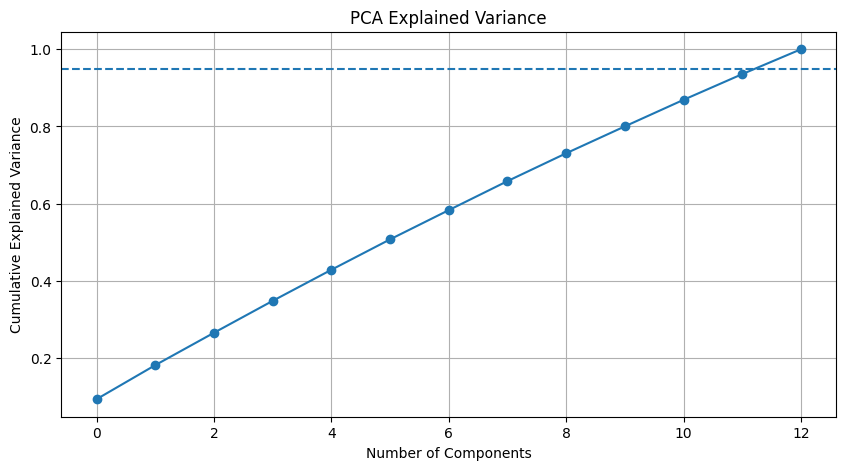

In [16]:
import matplotlib.pyplot as plt
import numpy as np

explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(
    explained_variance
)

plt.figure(figsize=(10, 5))

plt.plot(
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.xlabel("Number of Components")

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.grid(True)

plt.show()

In [17]:
loading_matrix = pd.DataFrame(
    pca.components_.T,
    columns=[
        f"PC_{i+1}"
        for i in range(
            pca.n_components_
        )
    ],
    index=X.columns
)

print(
    loading_matrix
)

                             PC_1      PC_2      PC_3      PC_4      PC_5  \
Throughput_Mbps         -0.349622 -0.379069  0.080865  0.373745 -0.006781   
Latency_ms               0.290582  0.332916  0.291533  0.213632  0.249252   
Packet_Loss_Percent      0.212234 -0.403125 -0.197624  0.218544  0.156036   
Active_Users             0.210686  0.278611 -0.352130 -0.312940 -0.116928   
PRB_Utilization_Percent -0.346669  0.231754  0.013178  0.128186 -0.063276   
SINR_dB                  0.449053 -0.143791  0.073291 -0.144998 -0.129146   
CQI                     -0.045992  0.015632  0.392444 -0.005436  0.461330   
CPU_Usage_Percent        0.174467  0.067669 -0.330119  0.456325  0.442664   
Memory_Usage_Percent     0.134877  0.423258  0.237443  0.289120 -0.418296   
Handover_Success_Rate    0.402620 -0.067201  0.459280  0.104920  0.043665   
RRC_Success_Rate        -0.140335  0.266365 -0.019156 -0.413399  0.540341   
Session_Drop_Rate        0.369502 -0.264135 -0.174406 -0.168887  0.020860   